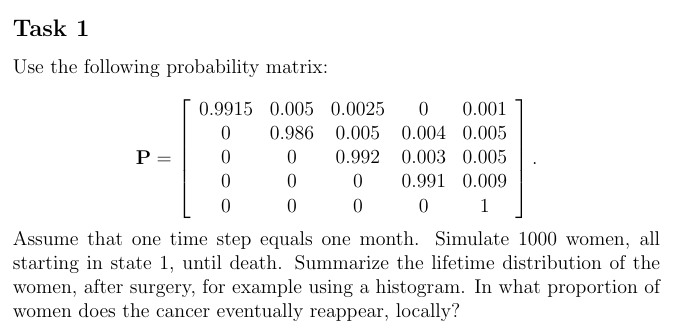

The goal of the first task is to simulate the progression of 1000 woman from state 1 to death (state 5) using the probability matrix given. To do this we use the following algorithm: 

1. Start in state 1 at time t = 0
2. While current state ≠ 5 (not dead):
   a. Look at row i of P (where i = current state)
   b. Sample next state j according to probabilities in row i
   c. Record the new state and increment time by 1 month
3. Record total lifetime (number of months until death)

We then repeat this for each of the 1000 women. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

P = np.array([
    [0.9915, 0.005,  0.0025, 0.0,    0.001],
    [0.0,    0.986,  0.005,  0.004,  0.005],
    [0.0,    0.0,    0.992,  0.003,  0.005],
    [0.0,    0.0,    0.0,    0.991,  0.009],
    [0.0,    0.0,    0.0,    0.0,    1.0]
])

Mean lifetime: 265.04 months
Median lifetime: 224.00 months
Min lifetime: 1 months
Max lifetime: 1151 months

Proportion with local recurrence: 0.5890 (58.90%)


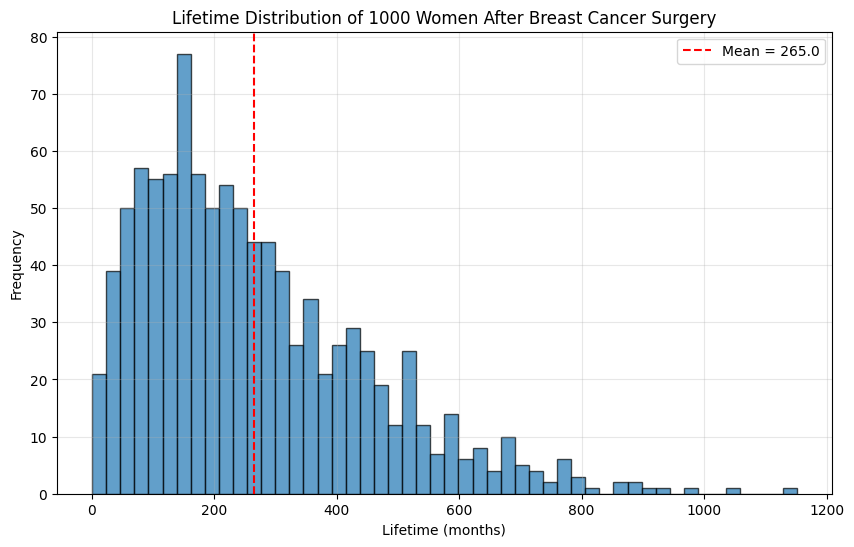

In [2]:
np.random.seed(42)
n_women = 1000

lifetimes = []
local_recurrence_flags = []

for _ in range(n_women):
    current_state = 0 
    time = 0
    ever_local_recurrence = False
    
    while True:
        if current_state == 1:
            ever_local_recurrence = True
            
        next_state = np.random.choice([0, 1, 2, 3, 4], p=P[current_state])
        
        time += 1
        
        if next_state == 4:
            break
            
        current_state = next_state
    lifetimes.append(time)
    local_recurrence_flags.append(ever_local_recurrence)

lifetimes = np.array(lifetimes)
local_recurrence_flags = np.array(local_recurrence_flags)

print(f"Mean lifetime: {lifetimes.mean():.2f} months")
print(f"Median lifetime: {np.median(lifetimes):.2f} months")
print(f"Min lifetime: {lifetimes.min()} months")
print(f"Max lifetime: {lifetimes.max()} months")

prop_local_recurrence = local_recurrence_flags.mean()
print(f"\nProportion with local recurrence: {prop_local_recurrence:.4f} ({prop_local_recurrence*100:.2f}%)")

# Histogram of lifetimes
plt.figure(figsize=(10, 6))
plt.hist(lifetimes, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Lifetime (months)')
plt.ylabel('Frequency')
plt.title('Lifetime Distribution of 1000 Women After Breast Cancer Surgery')
plt.axvline(lifetimes.mean(), color='red', linestyle='--', label=f'Mean = {lifetimes.mean():.1f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

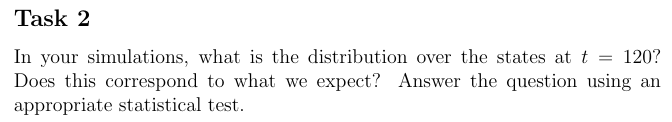

From the project itself we know that we can calculate the theoretical distribution as: 

$$p_{120} = p_0P^{120}$$

We can then find estimate this by running the same simulation as before and then log the state count of each state after 120 months and then normalise this to find the proportions. 

In [3]:
np.random.seed(42)
n_women = 10000

state_counts = np.array([0,0,0,0,0])
for _ in range(n_women):
    current_state = 0 
    time = 0
    ever_local_recurrence = False
    
    while True:
        if current_state == 1:
            ever_local_recurrence = True
            
        next_state = np.random.choice([0, 1, 2, 3, 4], p=P[current_state])
        
        time += 1
        
        if time > 119:
            state_counts[current_state] += 1
            break
            
        current_state = next_state

state_probabilities = state_counts / state_counts.sum()
print("\nEstimated State probabilities at 10 years (120 months):", state_probabilities)

p_0 = P[0]
p_120 = p_0 @ np.linalg.matrix_power(P, 119)
print("\nState probabilities at 10 years (120 months) using matrix power:", p_120)


Estimated State probabilities at 10 years (120 months): [0.3593 0.1654 0.164  0.0649 0.2464]

State probabilities at 10 years (120 months) using matrix power: [0.35902627 0.15895604 0.1660869  0.06774149 0.2481893 ]


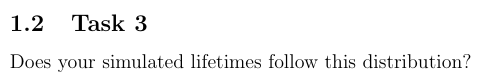

We are told that the distribution we plotted in the first task can be modelled by a phase-type distribution of the form: 

$$P(T=t) = \pi(\textbf{P}_s)^t\textbf{p}_s$$

with mean: 

$$E(T) = \pi(\textbf{I}-\textbf{P}_s)\textbf{1}$$

Where $\pi$ is the distribution over states 1,2,3,4 at t = 0, $\textbf{P}_s$ is a submatrix derived by removing the last row and column from $\textbf{P}$ and $\textbf{p}_s$ is column
vector indicating the probability of dying from states 1,2,3,4.


Theoretical Expected lifetime 261.37161531279304

Estimated Expected lifetime 265.035


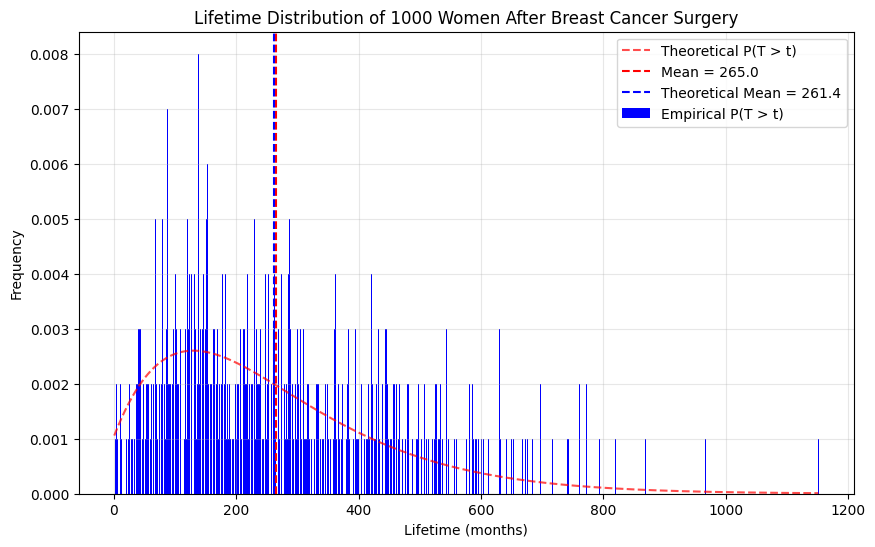

In [4]:
import numpy as np

pi = P[0][0:4]

Ps = P[0:4, 0:4]

I = np.eye(4)

ps = P[:4, 4]

E = pi @ np.linalg.inv(np.eye(4) - Ps) @ np.ones(4)

print("\nTheoretical Expected lifetime", E)
print("\nEstimated Expected lifetime", lifetimes.mean())

t_max = int(np.max(lifetimes))
t_vals = np.arange(1, t_max + 1)

P_t = np.array([pi @ np.linalg.matrix_power(Ps, t) @ ps for t in t_vals])
counts = np.bincount(lifetimes)
pmf_emp = counts[1:t_max+1] / len(lifetimes)

plt.figure(figsize=(10, 6))
plt.bar(t_vals, pmf_emp, label='Empirical P(T > t)', color='blue')
plt.plot(t_vals, P_t, '--', color='red', alpha=0.7, label='Theoretical P(T > t)')
plt.xlabel('Lifetime (months)')
plt.ylabel('Frequency')
plt.title('Lifetime Distribution of 1000 Women After Breast Cancer Surgery')
plt.axvline(lifetimes.mean(), color='red', linestyle='--', label=f'Mean = {lifetimes.mean():.1f}')
plt.axvline(E, color='blue', linestyle='--', label=f'Theoretical Mean = {E:.1f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

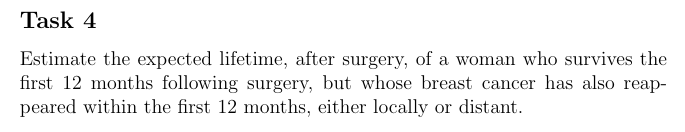

As the hist suggests we use rejection sampling to do this by rejection those who do not fit the criteria and then doing this until we have sampled 1000 woman. 

In [5]:
np.random.seed(42)
lifetimes = []
n_woman = 0

while n_woman < 1000:
    current_state = 0 
    time = 0
    ever_local_recurrence = False
    ever_distant_recurrence = False
    
    while True:
        if current_state == 1 and time <= 12:
            ever_local_recurrence = True
        if current_state == 3 and time <= 12:
            ever_distant_recurrence = True
            
        next_state = np.random.choice([0, 1, 2, 3, 4], p=P[current_state])
        time += 1
        
        if next_state == 4 and time > 12 and (ever_local_recurrence or ever_distant_recurrence):
            n_woman += 1
            lifetimes.append(time)
            break
        if time > 12 and not (ever_local_recurrence or ever_distant_recurrence):
            break
            
        current_state = next_state

lifetimes = np.array(lifetimes)
print(f"Expected lifetime: {lifetimes.mean():.2f} months")
print(f"Sample size: {len(lifetimes)}")

Expected lifetime: 165.53 months
Sample size: 1000


We solve this problem by recording the lifetime of all of the 200 woman in the inner loop. We then record both the fraction of those dying within 350 months ($Y_i$) and the mean lifetime of all of the 200 woman $(X_i)$. We then use $X_i$ as our control variate

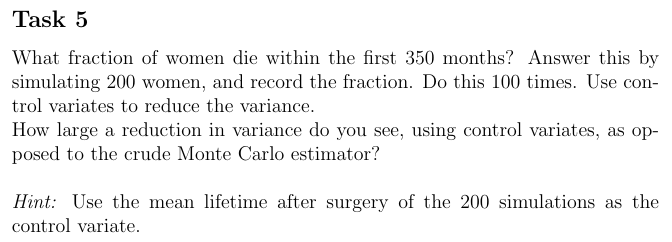

In [ ]:
np.random.seed(42)
n_simulations = 100
n_women = 200
fraction_results = []
mean_lifetime_results = []
for _ in range(n_simulations):
    deaths_within_350 = 0
    lifetimes = []
    for _ in range(n_women):
        current_state = 0 
        time = 0
        ever_local_recurrence = False
        
        while True:
                
            next_state = np.random.choice([0, 1, 2, 3, 4], p=P[current_state])
            
            time += 1
            if next_state == 4 and time <= 350:
                deaths_within_350 += 1
                lifetimes.append(time)
                break
            elif next_state == 4:
                lifetimes.append(time)
                break
            current_state = next_state
            

    fraction = deaths_within_350 / n_women
    fraction_results.append(fraction)
    mean_lifetime_results.append(np.mean(lifetimes))

Y = np.array(fraction_results)
X = np.array(mean_lifetime_results)

# Crude monte carlo
theta_crude = np.mean(Y)
var_crude = np.var(Y, ddof=1)

X_mu = 265.04

cov_YX = np.cov(Y, X, ddof=1)[0, 1]
var_X = np.var(X, ddof=1)
beta = cov_YX / var_X

Z = Y - beta * (X - X_mu)
theta_cv = np.mean(Z)
var_cv = np.var(Z, ddof=1)

variance_reduction = (var_crude - var_cv) / var_crude

print(f"Crude MC estimator:      {theta_crude:.4f}")
print(f"Control Variate estimator: {theta_cv:.4f}")
print(f"Variance of Y (crude):     {var_crude:.6f}")
print(f"Variance of Z (CV):        {var_cv:.6f}")
print(f"Variance reduction:        {variance_reduction:.2%}")

Crude MC estimator:      0.7375
Control Variate estimator: 0.7315
Variance of Y (crude):     0.001301
Variance of Z (CV):        0.000309
Variance reduction:        76.25%


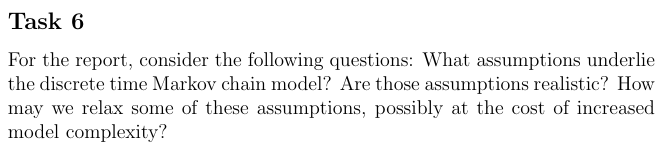

The discrete Markov chain model generally use three large assumptions:

- Time-steps are discrete
- The different cancer states works in discrete states
- The current time-step depends only on the previous (memoryless)

This means that the model assumes that changes between states are instantaneous and that the states themselves does not progress within the states and rather are all completely homogenous. This is quite unrealistic as cancer growth is a continuous process over time and does not happen in discrete time-steps. Also within each state, there might be differences between patients and between time-steps. The last assumption is also unrealistic as patient history can be very important for future disease progression.

We can relax these assumptions by switching to a continuous time Markov chain model which sould relax the first assumption. We can also relax the second assumption by switching to another model type that does not model disease progression as discrete steps. The memoryless property can also be relaxed however at the cost of higher computationel costs. Other model types might also not model the disease progress aswell or have higher parameter counts resulting in higher computational costs.

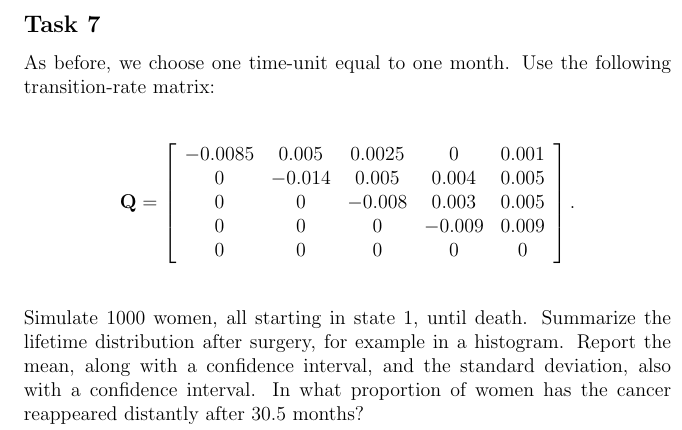

We start by defining the transition-rate matrix in python

In [7]:
import numpy as np

Q = np.array([
    [-0.0085, 0.005,  0.0025, 0.0,    0.001],
    [0.0,    -0.014,  0.005,  0.004,  0.005],
    [0.0,    0.0,    -0.008,  0.003,  0.005],
    [0.0,    0.0,    0.0,    -0.009,  0.009],
    [0.0,    0.0,    0.0,    0.0,    0.0]
])

Now we perform the same simulation as in task 1, however, now we use the continuous time markov chain model with the given transition-rate matrix.

Mean lifetime: 256.37 months (95% CI: 244.32, 268.42)
Std. dev. lifetime: 194.38 months (95% CI: 186.22, 203.29)
Median lifetime: 216.84 months
Min lifetime: 0.58 months
Max lifetime: 1372.82 months
Proportion with distant recurrence by 30.5 months: 0.076 (95% CI: 0.060, 0.092)


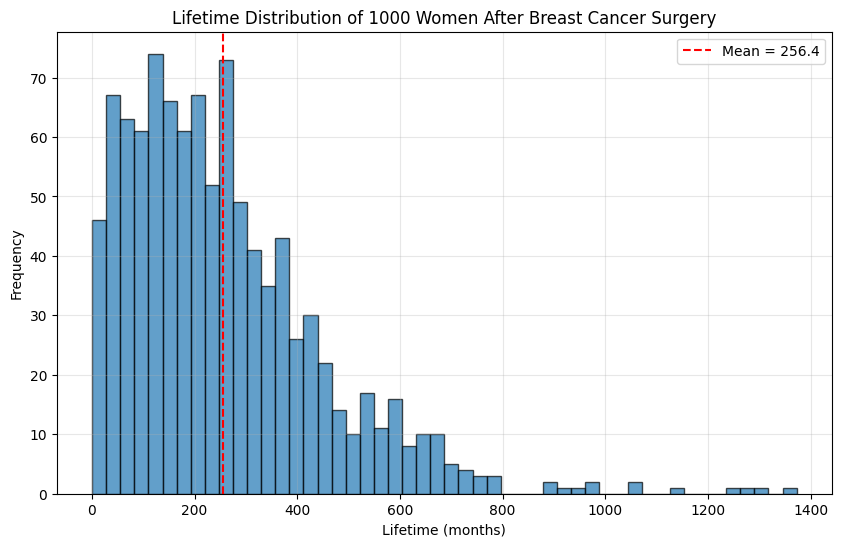

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
n_women = 1000

lifetimes = []
distant_by_target = []
death_state = 4
distant_state = 2
target_time = 30.5
for _ in range(n_women):
    current_state = 0 
    time = 0
    distant_time = np.inf
    while current_state != death_state:
        rate = -Q[current_state, current_state]
        
        state_time = np.random.exponential(1/rate)
        time += state_time

        p = Q[current_state].copy()
        p[current_state] = 0.0
        p = p / p.sum()

        next_state = np.random.choice([0, 1, 2, 3, 4], p=p)
        
        if next_state == distant_state and distant_time == np.inf:
            distant_time = time

        current_state = next_state

    lifetimes.append(time)
    distant_by_target.append(distant_time <= target_time)

lifetimes = np.array(lifetimes)
distant_by_target = np.array(distant_by_target)

mean_lifetime = lifetimes.mean()
std_lifetime = lifetimes.std(ddof=1)
sem = std_lifetime / np.sqrt(n_women)

# 95% confidence intervals
z = stats.norm.ppf(0.975)
ci_mean = (mean_lifetime - z * sem, mean_lifetime + z * sem)

# CI for standard deviation via chi-square on variance
chi_low = stats.chi2.ppf(0.025, df=n_women - 1)
chi_high = stats.chi2.ppf(0.975, df=n_women - 1)
ci_std = (
    std_lifetime * np.sqrt((n_women - 1) / chi_high),
    std_lifetime * np.sqrt((n_women - 1) / chi_low)
)

prop_distant = distant_by_target.mean()
ci_prop = (
    prop_distant - z * np.sqrt(prop_distant * (1 - prop_distant) / n_women),
    prop_distant + z * np.sqrt(prop_distant * (1 - prop_distant) / n_women)
)

print(f"Mean lifetime: {mean_lifetime:.2f} months (95% CI: {ci_mean[0]:.2f}, {ci_mean[1]:.2f})")
print(f"Std. dev. lifetime: {std_lifetime:.2f} months (95% CI: {ci_std[0]:.2f}, {ci_std[1]:.2f})")
print(f"Median lifetime: {np.median(lifetimes):.2f} months")
print(f"Min lifetime: {lifetimes.min():.2f} months")
print(f"Max lifetime: {lifetimes.max():.2f} months")
print(f"Proportion with distant recurrence by {target_time} months: "
      f"{prop_distant:.3f} (95% CI: {ci_prop[0]:.3f}, {ci_prop[1]:.3f})")

# Histogram
plt.figure(figsize=(10, 6))
plt.hist(lifetimes, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Lifetime (months)')
plt.ylabel('Frequency')
plt.title('Lifetime Distribution of 1000 Women After Breast Cancer Surgery')
plt.axvline(mean_lifetime, color='red', linestyle='--', label=f'Mean = {mean_lifetime:.1f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

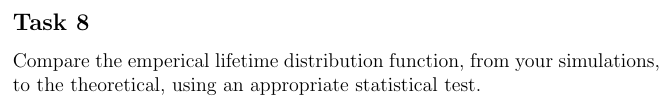

We are told to perform the same task as in task 3, however, with a continuous time markov chain model the phase type distribution now have the form: 

$$F_T(t) = 1 - \textbf{p}_0\text{exp}(\textbf{Q}_st)\textbf{1}$$

Where $\textbf{Q}_s$ is a submatrix like in the previous task.

KS statistic: 0.0239
p-value: 0.6110


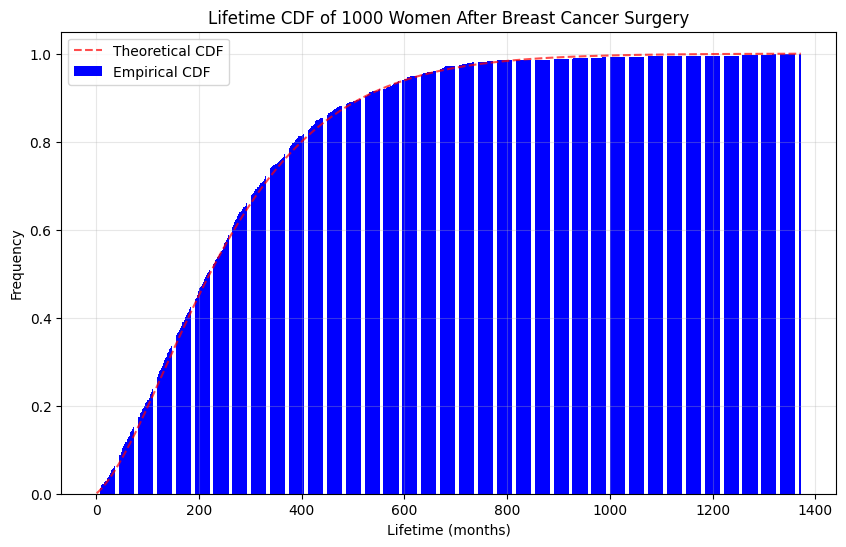

In [9]:
import scipy
import scipy.stats as stats
Qs = Q[:4, :4]
t_max = int(np.max(lifetimes))
t_vals = np.arange(1, t_max + 1)

p0 = np.array([1.0, 0.0, 0.0, 0.0])   # all women start in state 1

def phase_type_cdf(t):
    t = np.atleast_1d(t)
    values = np.array([
        1 - p0 @ scipy.linalg.expm(Qs * x) @ np.ones(4)
        for x in t
    ])
    return values if len(values) > 1 else values[0]

ks_statistic, p_value = stats.kstest(lifetimes, phase_type_cdf)
print(f"KS statistic: {ks_statistic:.4f}")
print(f"p-value: {p_value:.4f}")

F_t = np.array([1 - p0 @ scipy.linalg.expm(Qs * t) @ np.ones(4) for t in t_vals])

pmf_emp = np.bincount(lifetimes.astype(int))[1:t_max+1] / len(lifetimes)
cdf_emp = np.cumsum(pmf_emp)

plt.figure(figsize=(10, 6))
plt.bar(t_vals, cdf_emp, label='Empirical CDF', color='blue')
plt.plot(t_vals, F_t, '--', color='red', alpha=0.7, label='Theoretical CDF')
plt.xlabel('Lifetime (months)')
plt.ylabel('Frequency')
plt.title('Lifetime CDF of 1000 Women After Breast Cancer Surgery')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

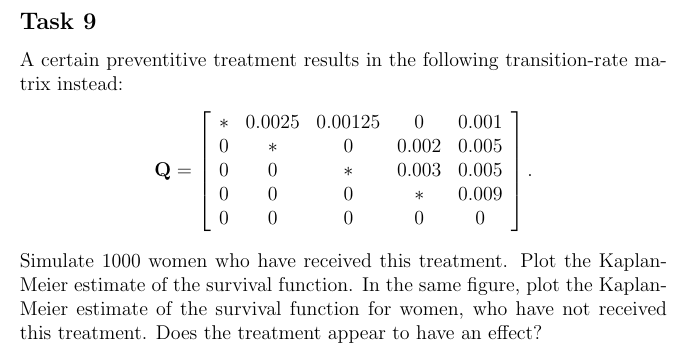

As explained in the problem formulation, we can estimate the survival function using the Kaplan-Meier estimator:

$$\hat{S}(t) = \frac{N - d(t)}{N}$$

We start by defining the new treatment transition-Rate matrix.

In [12]:
import numpy as np

Q_treatment = np.array([
    [0.0, 0.0025,  0.00125, 0.0,    0.001],
    [0.0,    0.0,  0.0,  0.002,  0.005],
    [0.0,    0.0,    0.0,  0.003,  0.005],
    [0.0,    0.0,    0.0,    0.0,  0.009],
    [0.0,    0.0,    0.0,    0.0,    0.0]   
])

# Define diagonal
for i in range(5):
    Q_treatment[i, i] = -Q_treatment[i].sum() + Q_treatment[i, i]

We then run the simulation twice and record the number of woman who die in each timestep for both.

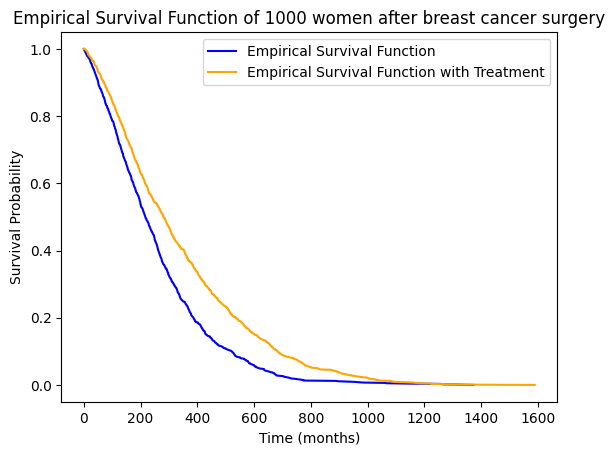

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
n_women = 1000

lifetimes_control = []
death_state = 4
death_time = 0
death_number = 0
dt = []
for _ in range(n_women):
    current_state = 0 
    time = 0
    while current_state != death_state:
        rate = -Q[current_state, current_state]
        
        state_time = np.random.exponential(1/rate)
        time += state_time

        p = Q[current_state].copy()
        p[current_state] = 0.0
        p = p / p.sum()

        next_state = np.random.choice([0, 1, 2, 3, 4], p=p)

        current_state = next_state
        if current_state == death_state:
            death_time += time
            death_number += 1
            dt.append(death_number)


    lifetimes_control.append(time)

lifetimes_control = np.array(lifetimes_control)
t_max = int(np.max(lifetimes_control))
n = len(lifetimes_control)
sorted_times = np.sort(lifetimes_control)
unique_times, counts = np.unique(sorted_times, return_counts=True)
at_risk = n - np.concatenate([[0], np.cumsum(counts)[:-1]])
survival = np.cumprod(1 - counts / at_risk)
km_times = np.concatenate([[0.0], unique_times])
km_survival = np.concatenate([[1.0], survival])

lifetimes = []
death_state = 4
for _ in range(n_women):
    current_state = 0 
    time = 0
    while current_state != death_state:
        rate = -Q_treatment[current_state, current_state]
        
        state_time = np.random.exponential(1/rate)
        time += state_time

        p = Q_treatment[current_state].copy()
        p[current_state] = 0.0
        p = p / p.sum()

        next_state = np.random.choice([0, 1, 2, 3, 4], p=p)

        current_state = next_state

    lifetimes.append(time)

lifetimes = np.array(lifetimes)
t_max = int(np.max(lifetimes))
n = len(lifetimes)
sorted_times = np.sort(lifetimes)
unique_times, counts = np.unique(sorted_times, return_counts=True)
at_risk = n - np.concatenate([[0], np.cumsum(counts)[:-1]])
survival = np.cumprod(1 - counts / at_risk)
km_times_treatment = np.concatenate([[0.0], unique_times])
km_survival_treatment = np.concatenate([[1.0], survival])
plt.plot(km_times, km_survival, label='Empirical Survival Function', color='blue')
plt.plot(km_times_treatment, km_survival_treatment, label='Empirical Survival Function with Treatment', color='orange')
plt.xlabel('Time (months)')
plt.ylabel('Survival Probability')
plt.title('Empirical Survival Function of 1000 women after breast cancer surgery')
plt.legend()
plt.show()

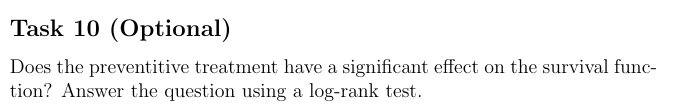

In [14]:
from lifelines.statistics import logrank_test

result = logrank_test(
    km_survival,
    km_survival_treatment
)

print("Test statistic:", result.test_statistic)
print("p-value:", result.p_value)
result.print_summary()

Test statistic: 0.0
p-value: 1.0


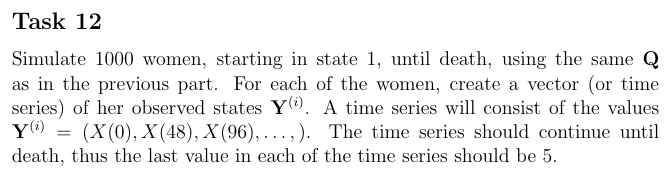

We run the simulation as in task 7 but only log the states in a time series which we store for each woman.

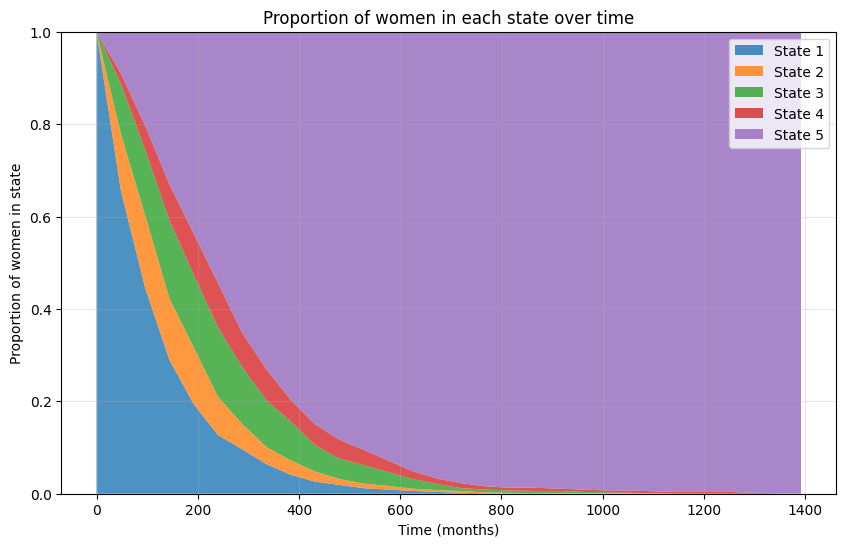

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

np.random.seed(42)

Q_true = np.array([
    [-0.0085, 0.005, 0.0025, 0, 0.001],
    [0, -0.014, 0.005, 0.004, 0.005],
    [0, 0, -0.008, 0.003, 0.005],
    [0, 0, 0, -0.009, 0.009],
    [0, 0, 0, 0, 0]
])

n_women = 1000
death_state = 4
interval = 48

observations = []

for i in range(n_women):
    current_state = 0
    time = 0.0
    times = []
    states = []

    while current_state != death_state:
        rate = -Q_true[current_state, current_state]
        state_time = np.random.exponential(1 / rate)
        time += state_time

        p = Q_true[current_state].copy()
        p[current_state] = 0.0
        p = p / p.sum()
        next_state = np.random.choice([0, 1, 2, 3, 4], p=p)

        times.append(time)
        states.append(next_state)
        current_state = next_state

    obs = [0]
    t = interval
    while True:
        idx = np.searchsorted(times, t, side='right') - 1
        if idx < 0:
            state_at_t = 0
        else:
            state_at_t = states[idx]
        obs.append(state_at_t)
        if state_at_t == death_state:
            break
        t += interval

    observations.append(obs)

# Pad every observation list with death state so they all have the same length
max_length = max(len(obs) for obs in observations)
for obs in observations:
    while len(obs) < max_length:
        obs.append(death_state)

# Build state proportions
state_proportions = np.zeros((5, max_length))
for obs in observations:
    for t, state in enumerate(obs):
        state_proportions[state, t] += 1
state_proportions /= n_women

# x-axis must be the actual time points in months
time_points = np.arange(0, max_length * interval, interval)

plt.figure(figsize=(10, 6))
plt.stackplot(
    time_points,
    state_proportions[0],
    state_proportions[1],
    state_proportions[2],
    state_proportions[3],
    state_proportions[4],
    labels=[f'State {i}' for i in range(1,6)],
    alpha=0.8
)
plt.xlabel('Time (months)')
plt.ylabel('Proportion of women in state')
plt.title('Proportion of women in each state over time')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

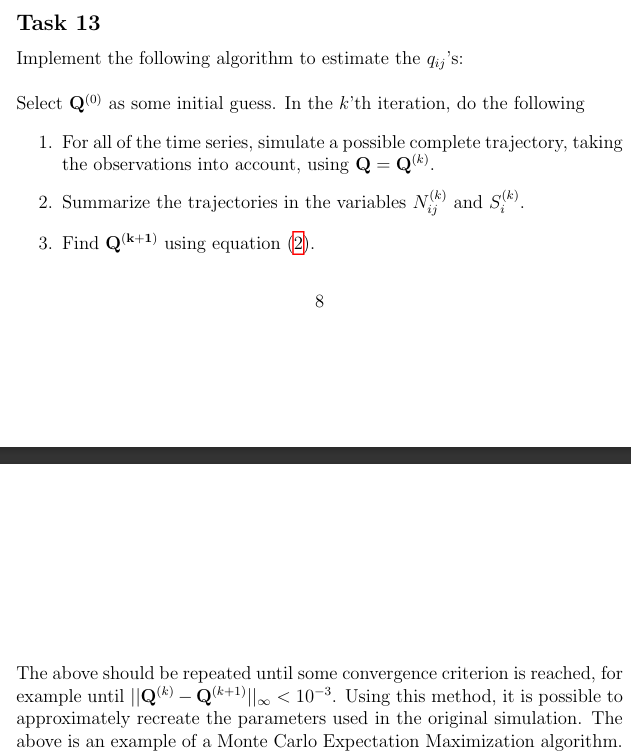

### Task 13: MCEM estimation of $Q$ from observed time series

Using the observations we simulated in the last task, we can estimate $Q$ as follows. We start with a randomly initiated $Q^{(0)}$, then for each interval, we simulate a latent CTMC path conditional on the start/end observed states (a bridge via rejection sampling), accumulate $N_{ij}^{(k)}$ and $S_i^{(k)}$, and update

$$q_{ij}^{(k+1)} = \frac{N_{ij}^{(k)}}{S_i^{(k)}},\; i\neq j, \qquad q_{ii}^{(k+1)} = -\sum_{j\neq i} q_{ij}^{(k+1)}.$$

Repeat until $\|Q^{(k+1)}-Q^{(k)}\|_F < 10^{-4}$ or reached 100 iterations.

Iteration 1: max diff = 0.019325
Iteration 2: max diff = 0.004774
Iteration 3: max diff = 0.003708
Iteration 4: max diff = 0.002202
Iteration 5: max diff = 0.000596
Iteration 6: max diff = 0.000413
Iteration 7: max diff = 0.000442
Iteration 8: max diff = 0.000456
Iteration 9: max diff = 0.000198
Iteration 10: max diff = 0.000439
Iteration 11: max diff = 0.000301
Iteration 12: max diff = 0.000427
Iteration 13: max diff = 0.000203
Iteration 14: max diff = 0.000423
Iteration 15: max diff = 0.000485
Iteration 16: max diff = 0.000759
Iteration 17: max diff = 0.000550
Iteration 18: max diff = 0.000393
Iteration 19: max diff = 0.000645
Iteration 20: max diff = 0.000158
Iteration 21: max diff = 0.000227
Iteration 22: max diff = 0.000376
Iteration 23: max diff = 0.000558
Iteration 24: max diff = 0.000304
Iteration 25: max diff = 0.000628
Iteration 26: max diff = 0.000399
Iteration 27: max diff = 0.000492
Iteration 28: max diff = 0.000519
Iteration 29: max diff = 0.000220
Iteration 30: max diff 

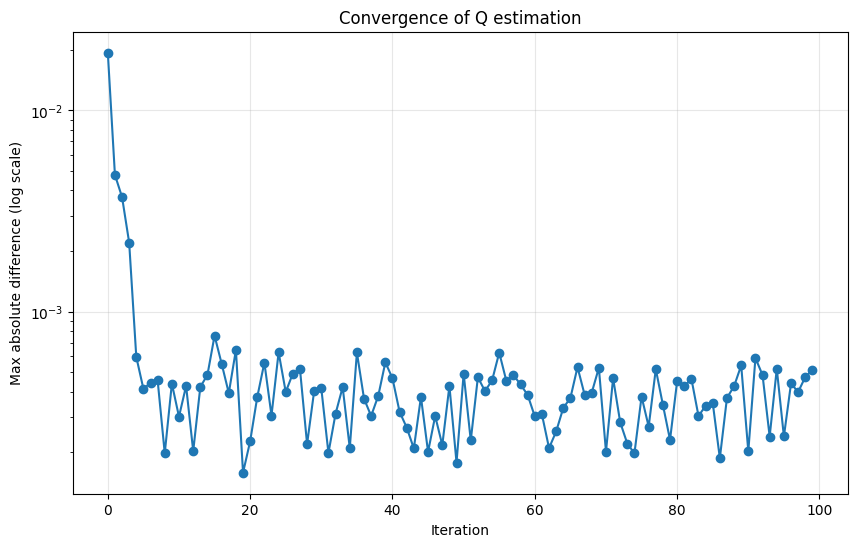

In [17]:
# Randomly inititate Q_est
Q_est = np.random.rand(5, 5) * 0.01
for i in range(5):
    Q_est[i, i] = -Q_est[i].sum() + Q_est[i, i]

max_iter = 100
tol = 1e-4
diffs = []
for iteration in range(max_iter):
    N = np.zeros((5, 5))
    S = np.zeros(5)

    for obs in observations:
        for k in range(len(obs) - 1):
            start = obs[k]
            end   = obs[k + 1]

            if start == death_state:
                S[death_state] += interval
                continue

            accepted = False
            while not accepted:
                current_state = start
                time = 0.0
                jump_times = []
                jump_states = []

                while time < interval and current_state != death_state:
                    rate = -Q_est[current_state, current_state]
                    state_time = np.random.exponential(1 / rate)

                    if time + state_time > interval:
                        break

                    time += state_time
                    p = Q_est[current_state].copy()
                    p[current_state] = 0.0
                    p = p / p.sum()
                    next_state = np.random.choice([0, 1, 2, 3, 4], p=p)

                    jump_times.append(time)
                    jump_states.append(next_state)
                    current_state = next_state

                if current_state == end:
                    accepted = True

            prev_t = 0.0
            current = start

            for t, s in zip(jump_times, jump_states):
                S[current] += t - prev_t
                N[current, s] += 1
                current = s
                prev_t = t

            S[current] += interval - prev_t

    Q_new = np.zeros((5, 5))
    for i in range(5):
        for j in range(5):
            if i != j and S[i] > 0:
                Q_new[i, j] = N[i, j] / S[i]
        Q_new[i, i] = -Q_new[i].sum()

    diff = np.max(np.abs(Q_new - Q_est))
    diffs.append(diff)
    print(f"Iteration {iteration + 1}: max diff = {diff:.6f}")

    if diff < tol:
        print("Converged!")
        Q_est = Q_new
        break

    Q_est = Q_new

print("\nEstimated Q:")
print(Q_est)
print("\nTrue Q:")
print(Q_true)

plt.figure(figsize=(10, 6))
plt.plot(diffs, marker='o')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Max absolute difference (log scale)')
plt.title('Convergence of Q estimation')
plt.grid(True, alpha=0.3)
plt.show()